### Preprocessing
- Dataset: Materials Project structures (April 2025)
  - Columns: Database, Reduced Formula, CIF, Bandgap (eV), Energy Above Hull (eV)
- Deduplicated, filters applied: 
  - removed negative and null bandgaps
- Cleaned for CIF augmentation, normalisations:
  - Bandgap - power-log ($\beta = 0.8$)
  - $E_{hull}$ - min-max
- Note: I didnt filter to context length here because it was not implemented yet, but filter to context was flagged as True during model training which effectively does the same thing (less efficient)
- Pushed to Huggingface as c-bone/mpdb-2prop_clean

### Training

In [ ]:
models = ['PKV', 'prepend', 'raw', 'slider']
regimes = ['ft', 'scratch']

for models in models:
    for regimes in regimes:
        config_path = f'_config_files/training/conditional/pretraining_benefits/mpdb_{regimes}-{models}.jsonc'

        !torchrun --nproc_per_node=2 _train.py --config config_path

### CIF Generation for each

In [ ]:
for models in models:
    for regimes in regimes:
        gen_config_path = f'_config_files/generation/conditional/pretraining_benefits/mpdb_{regimes}-{models}.jsonc'

        !python _utils/_generating/generate_CIFs.py --config gen_config_path

### Metrics for each

In [ ]:
for models in models:
    for regimes in regimes:
        gen_structs_path = f'_artifacts/pretrain_benefits/{regimes}-methods/mpdb_{regimes}-{models}_gen.parquet'

        postprocessed_path = f'_artifacts/pretrain_benefits/{regimes}-methods/mpdb-{regimes}-{models}_post.parquet'

        !python _utils/_metrics/VUN_metrics.py \
            --input_parquet gen_structs_path \
            --huggingface_dataset 'c-bone/mpdb-2prop_clean' \
            --load_processed_data 'HF-databases/mpdb-2prop_clean/mpdb_2prop_proc.parquet' \
            --output_parquet postprocessed_path \
            --num_workers 32

        !python _utils/_metrics/mace_ehull.py \
            --post_parquet postprocessed_path \
            --output_parquet postprocessed_path \
            --mp_data 'mp_computed_structure_entries.json.gz' \
            --num_workers 16

        !python _utils/_metrics/property_metrics.py \
            --post_parquet postprocessed_path \
            --output_parquet postprocessed_path \
            --property_targets ["Bandgap (eV)", "Energy Above Hull (eV)"] \
            --num_workers 16 \
            --property1_normaliser "power_log" \
            --property2_normaliser "linear" \
            --max_property1 17.891 \
            --min_property1 0.0 \
            --max_property2 5.418 \
            --min_property2 0.0

### results

Navigated to package root
Calculating Summary Metrics...
hit_rate_density_correlation: 0.6512
validity_density_correlation: 0.1182
quality_density_correlation: 0.1859
avg_delta_validity: 0.1233
sem_delta_validity: 0.0823
avg_delta_quality: 0.1061
sem_delta_quality: 0.0380
avg_delta_hit_rate: 0.0055
sem_delta_hit_rate: 0.0211

Generating Pretraining Benefits Plot...


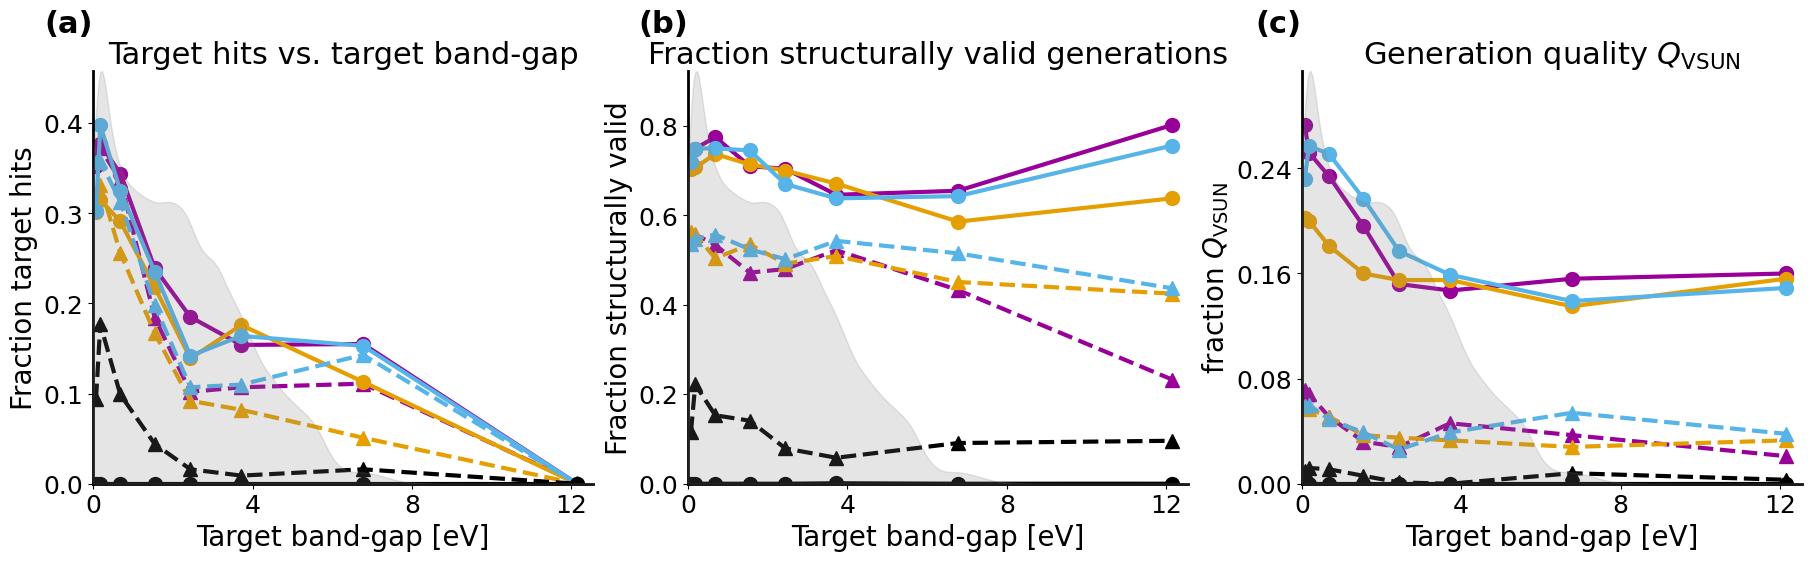


Generating Parity Grid and Table...


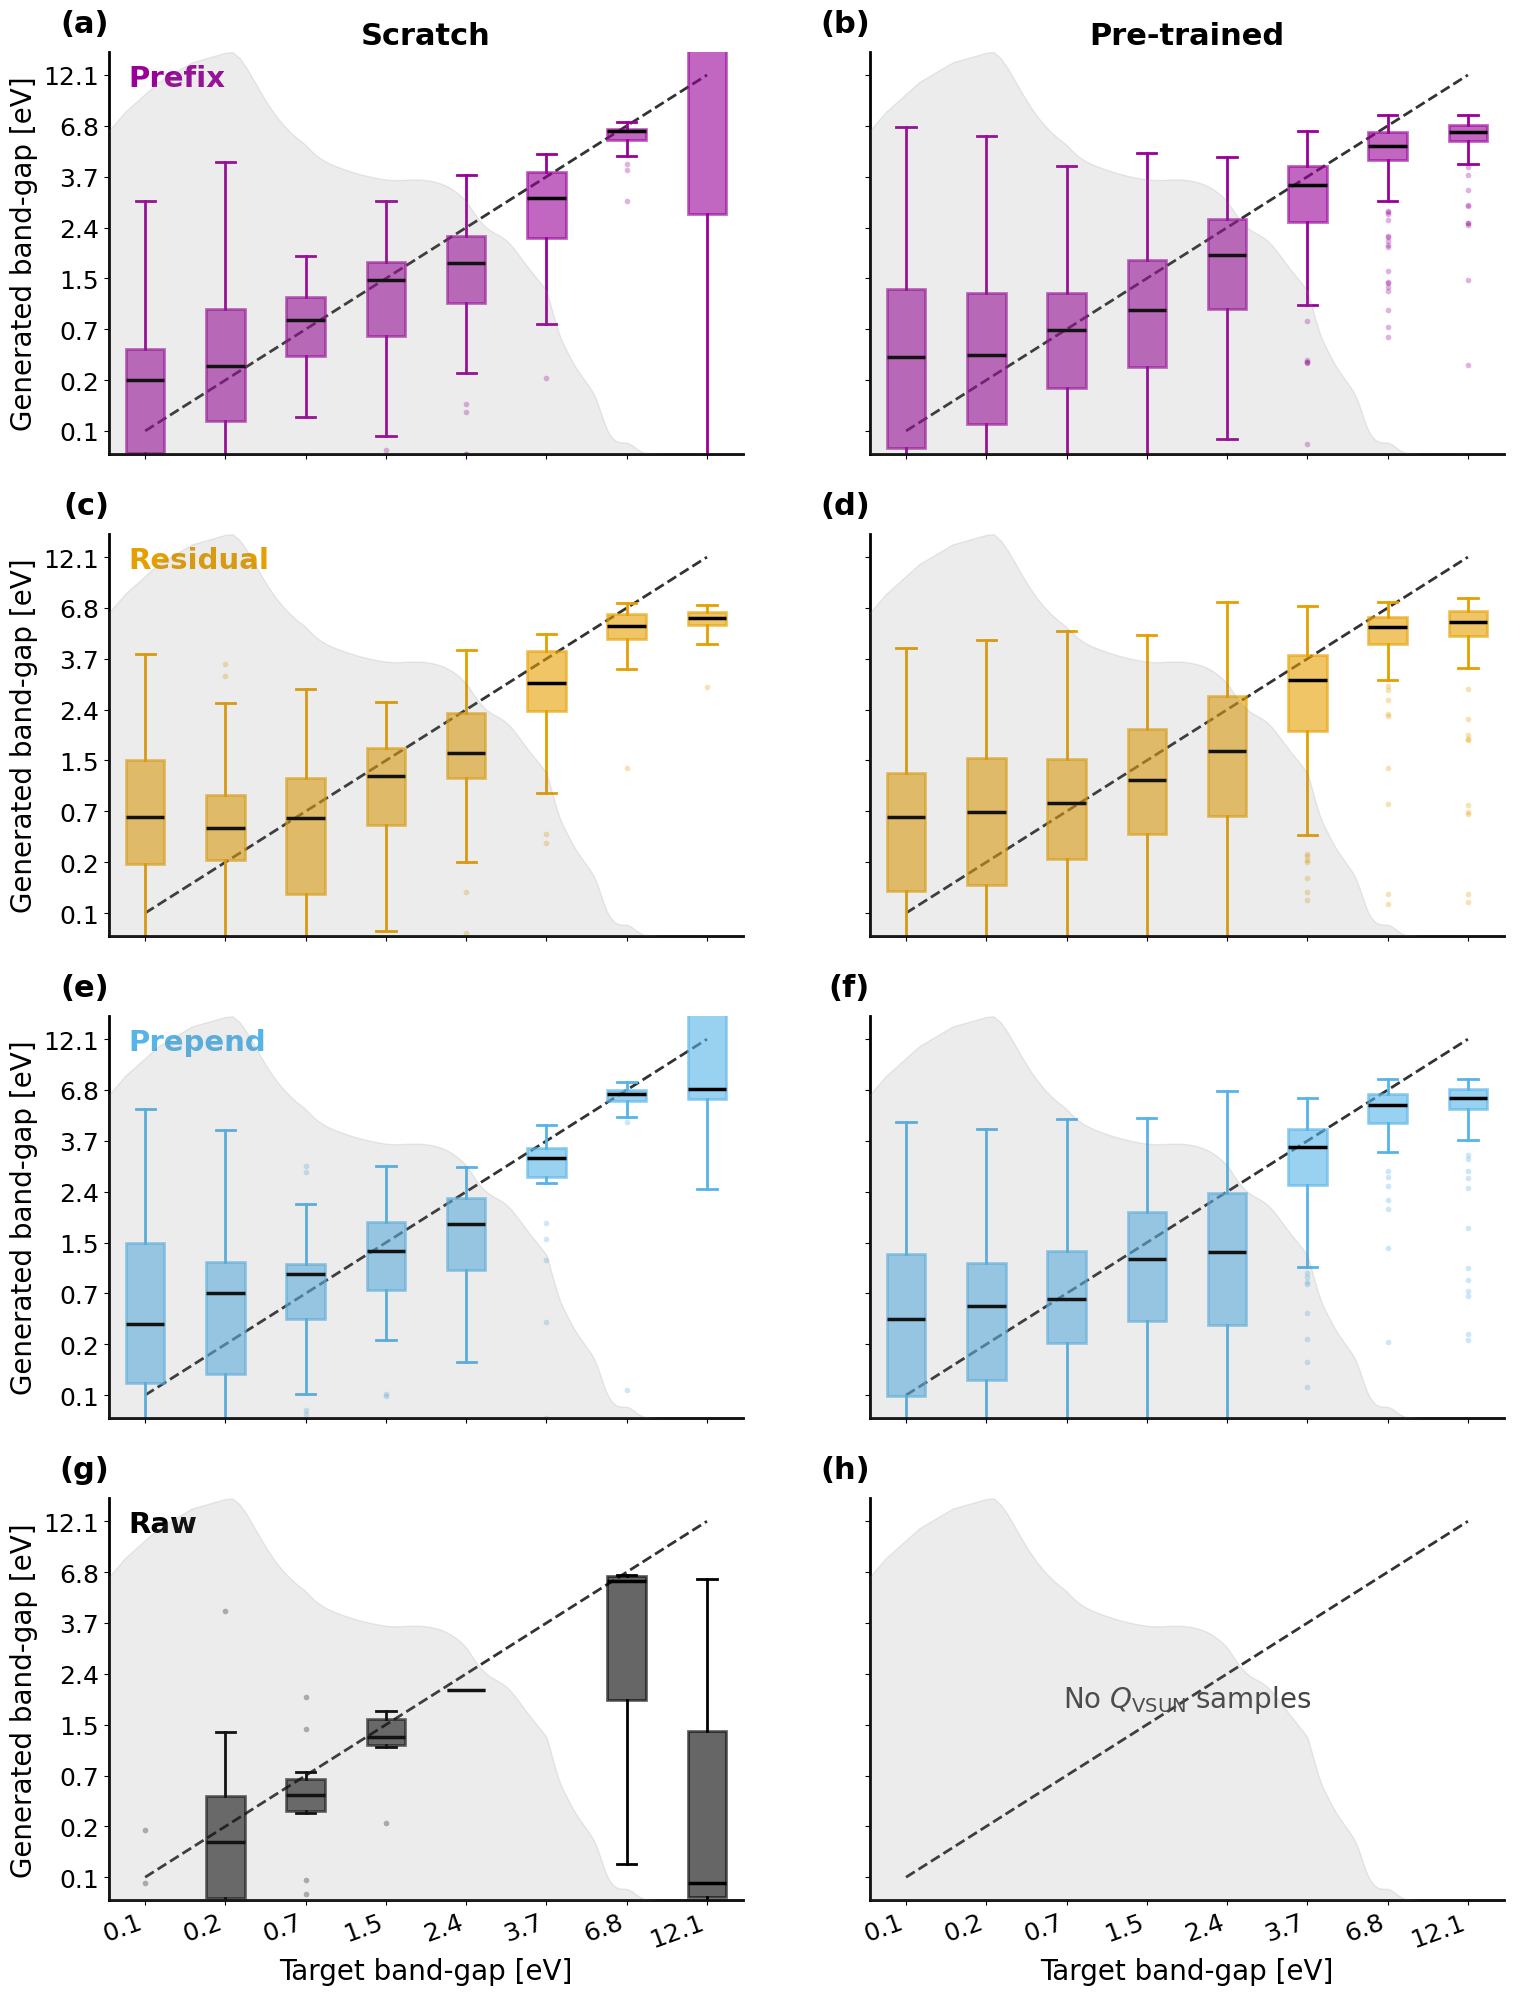


VSUN Parity Grid Metrics Table:
     Regime    Model $R^2$ MAE (+/- SE)  N Structurally Valid Structurally Valid Target Yield (%) VSUN Target Yield (%)
    Scratch   Prefix  0.60 1.03 (0.093)                  3788                               19.70                  2.53
    Scratch Residual  0.61 1.40 (0.099)                  4036                               16.07                  1.47
    Scratch  Prepend  0.65 1.30 (0.098)                  4162                               19.82                  2.10
    Scratch      Raw  0.22 1.27 (0.383)                   956                                5.69                  0.45
Pre-trained   Prefix  0.59 1.48 (0.047)                  5759                               22.57                  7.52
Pre-trained Residual  0.51 1.69 (0.056)                  5457                               19.43                  5.39
Pre-trained  Prepend  0.58 1.46 (0.046)                  5670                               21.50                  7.21
Pre-tra

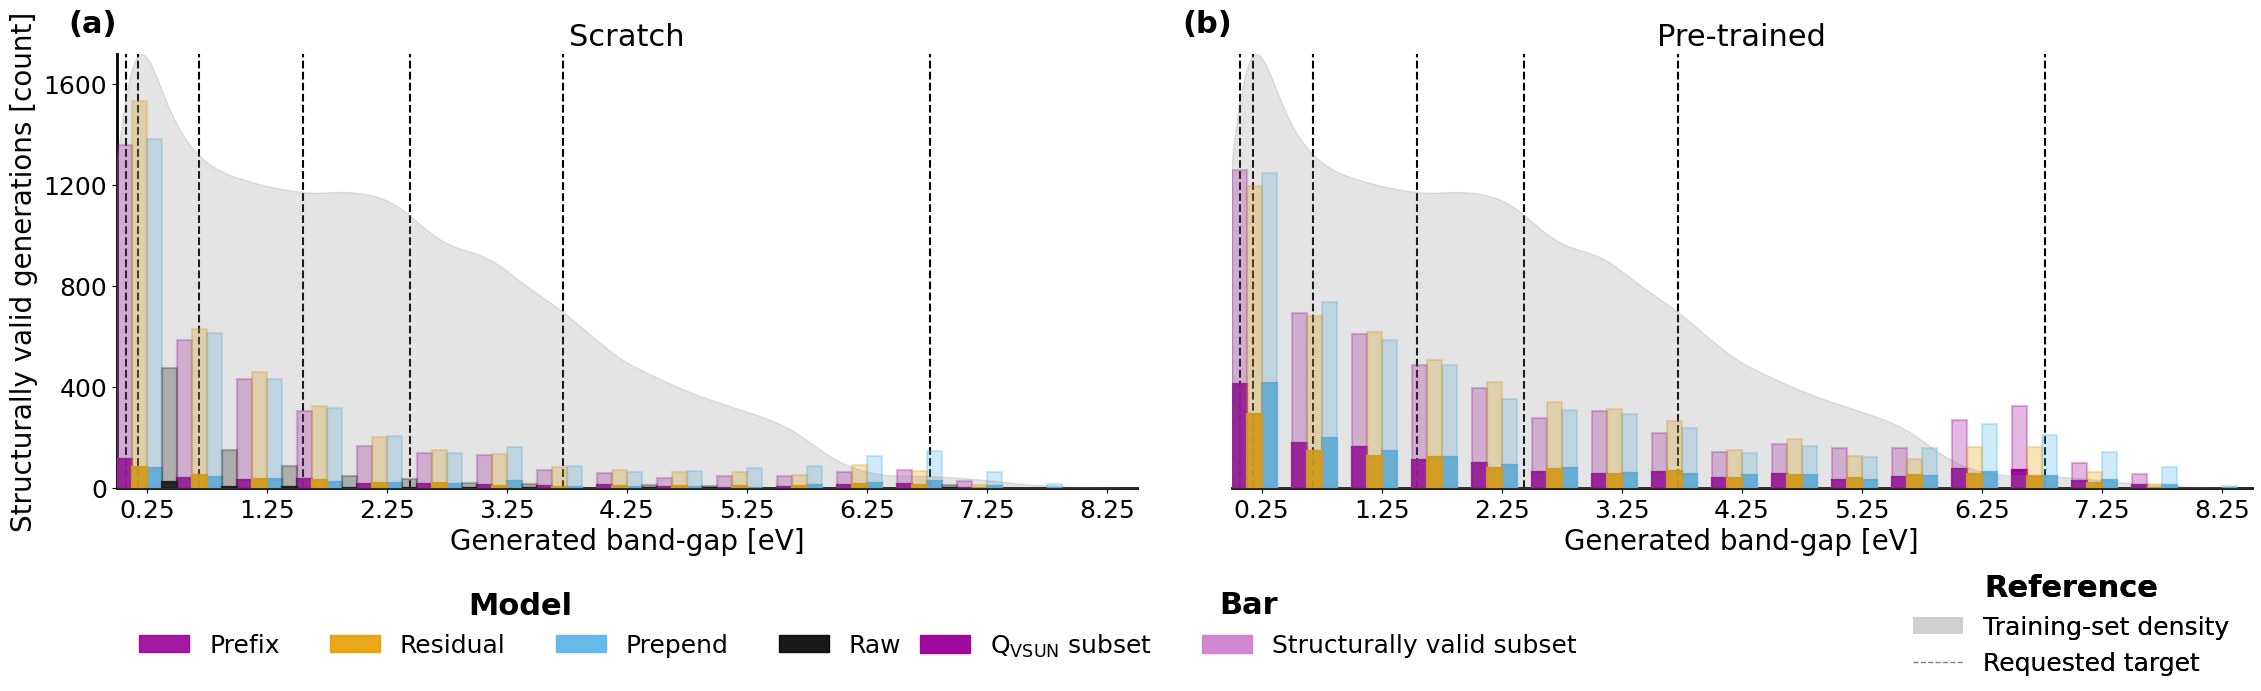

In [1]:
import __init__
import os
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from _utils._notebook_utils.b1a_pretrain_benefits_utils import (
    get_metrics_ptnd_vs_scratch,
    plot_pretraining_benefits,
    plot_vsun_parity_grid_bandgap,
    format_bandgap_metrics_table,
    plot_bandgap_output_space_summary
)

MODELS = ['PKV', 'prepend', 'raw', 'slider']
REGIMES = ['ft', 'scratch']
BASE_ARTIFACT_DIR = '_artifacts/pretrain_benefits'
OUTPUT_DIR = 'plots/bg'
os.makedirs(OUTPUT_DIR, exist_ok=True)

dfs_pretrain = {}
for model in MODELS:
    for regime in REGIMES:
        filepath = f'{BASE_ARTIFACT_DIR}/{regime}-methods/mpdb-{regime}-{model}_post.parquet'
        dfs_pretrain[f'mpdb_{model}_{regime}'] = pd.read_parquet(filepath)

ds = load_dataset('c-bone/mpdb-2prop_clean', split='train')
train_df = ds.to_pandas()

print("Calculating Summary Metrics...")
metrics = get_metrics_ptnd_vs_scratch(
    dfs_pretrain,
    train_df=train_df,
 )
pd.DataFrame([metrics]).to_csv(
    os.path.join(OUTPUT_DIR, 'pretraining_benefits_summary_metrics.csv'),
    index=False,
 )

print("\nGenerating Pretraining Benefits Plot...")
fig_top = plot_pretraining_benefits(
    dfs_pretrain,
    train_df=train_df,
    target_bg_col="target_Bandgap (eV)",
    label_fontsize=20,
    title_fontsize=22,
    ticks_fontsize=18,
    line_width=3.0,
    marker_size=10,
    axes_thickness=2.0,
    figsize=(18, 5.5)
)
fig_top.savefig(
    os.path.join(OUTPUT_DIR, 'pretraining_benefits_plot.png'),
    dpi=300,
    bbox_inches='tight',
)
plt.show()

print("\nGenerating Parity Grid and Table...")
fig_bandgap, metrics_df = plot_vsun_parity_grid_bandgap(
    dfs_pretrain,
    train_df=train_df,
    figsize=(18, 24),
    line_width=2.5,
    scatter_size=150,
    axes_linewidth=2.0,
    num_yticks=5,
    num_yticks_ref=3,
    title_fontsize=22,
    label_fontsize=20,
    ticks_fontsize=18,
)
fig_bandgap.savefig(
    os.path.join(OUTPUT_DIR, 'pretraining_benefits_parity_grid.png'),
    dpi=300,
    bbox_inches='tight',
)
plt.show()

formatted_table = format_bandgap_metrics_table(metrics_df)
formatted_table.to_csv(
    os.path.join(OUTPUT_DIR, 'pretraining_benefits_parity_table.csv'),
    index=False,
 )
with open(os.path.join(OUTPUT_DIR, 'pretraining_benefits_parity_table.tex'), 'w') as handle:
    handle.write(formatted_table.to_latex(index=False, escape=False))
print("\nVSUN Parity Grid Metrics Table:")
print(formatted_table.to_string(index=False))

fig_bandgap_output = plot_bandgap_output_space_summary(
    dfs_pretrain,
    train_df=train_df,
    figsize=(22.5, 6.8),
    wspace=0.02,
    hspace=0.05,
    axes_linewidth=2.0,
    num_yticks=5,
    num_yticks_ref=3,
    title_fontsize=22,
    label_fontsize=20,
    ticks_fontsize=18,
)
fig_bandgap_output.savefig(
    os.path.join(OUTPUT_DIR, 'pretraining_benefits_output_space.png'),
    dpi=300,
    bbox_inches='tight',
)

plt.show()